# Exploratory Data Analysis — Univariate EDA

**Contributors:** Jeff [Nachname], [Teammate 1], [Teammate 2]

**Course:** Data Analytics & Applications, TH Nürnberg (Georg Simon Ohm)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

---
# 1) Autonomous Vehicle Survey of Bicyclists and Pedestrians in Pittsburgh

## 1.1 Load the survey data for 2019

In [22]:
# Load the combined 2019 survey data prepared in the previous lab (adjust filepath if needed)
df_av = pd.read_csv("data/av_survey_data/avsurvey2019data.csv", encoding="latin-1")
print(f"Shape: {df_av.shape}")
df_av.head()

Shape: (795, 23)


,RespondentID,StartDate,EndDate,FamiliarityNews,FamiliarityTech,SharedCyclist,SharedPedestrian,SafeAv,SafeHuman,AvImpact,...,SchoolZoneManual,ShareTripData,SharePerformanceData,ReportSafetyIncident,ArizonaCrash,ZipCode,BikePghMember,AutoOwner,SmartphoneOwner,Age
0,10505419886,2/2/2019,2/2/2019,To a moderate extent,Somewhat familiar,Yes,Yes,4.0,2.0,Significantly Better,...,No,Not sure,Yes,Yes,No change,15212,No,Yes,Yes,25-34
1,10505138734,2/2/2019,2/2/2019,To a moderate extent,Somewhat familiar,Yes,No,5.0,4.0,Significantly Better,...,No,No,Yes,Not sure,No change,15232,Not sure,Yes,Yes,25-34
2,10504803283,2/1/2019,2/1/2019,To a moderate extent,Somewhat familiar,Yes,Yes,1.0,4.0,Significantly Worse,...,No,No,No,Not sure,Significantly more negative opinion,NaN,No,No,No,NaN
3,10504337177,2/1/2019,2/1/2019,To a moderate extent,Extremely familiar,Yes,Yes,2.0,3.0,Slightly Worse,...,Yes,No,Yes,Yes,No change,15136,No,No,Yes,55-64
4,10504261546,2/1/2019,2/1/2019,To a moderate extent,Mostly familiar,Yes,No,5.0,3.0,Slightly Better,...,Not sure,Yes,Yes,No,No change,15201,Yes,No,Yes,35-44


In [23]:
df_av.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795 entries, 0 to 794
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RespondentID          795 non-null    int64  
 1   StartDate             795 non-null    object 
 2   EndDate               795 non-null    object 
 3   FamiliarityNews       794 non-null    object 
 4   FamiliarityTech       794 non-null    object 
 5   SharedCyclist         792 non-null    object 
 6   SharedPedestrian      793 non-null    object 
 7   SafeAv                787 non-null    float64
 8   SafeHuman             792 non-null    float64
 9   AvImpact              788 non-null    object 
 10  ProvingGround         792 non-null    object 
 11  Speed25Mph            792 non-null    object 
 12  TwoEmployeesAv        792 non-null    object 
 13  SchoolZoneManual      793 non-null    object 
 14  ShareTripData         793 non-null    object 
 15  SharePerformanceData  7

## 1.2 Bar chart of the top 5 variables with the most missing values

ZipCode          32
SafeAv            8
BikePghMember     8
AvImpact          7
Age               7
dtype: int64


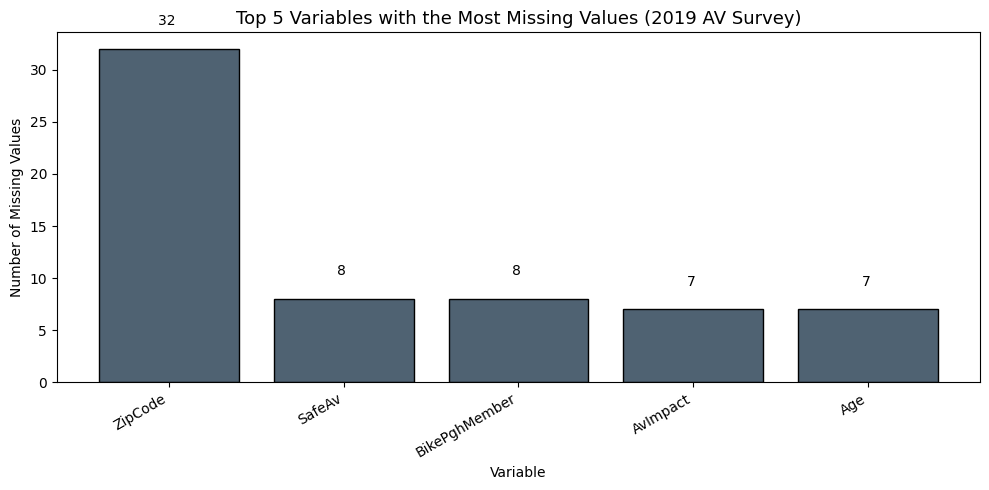

In [24]:
# Count missing values per column and select the top 5
missing = df_av.isnull().sum().sort_values(ascending=False).head(5)
print(missing)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(missing.index, missing.values, color='#4f6272', edgecolor='black')

# Add value labels and percentage on top of each bar
total_rows = len(df_av)
for bar, val in zip(bars, missing.values):
    
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val} ", ha='center', va='bottom', fontsize=10)

ax.set_title('Top 5 Variables with the Most Missing Values (2019 AV Survey)', fontsize=13)
ax.set_ylabel('Number of Missing Values')
ax.set_xlabel('Variable')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 1.3 Analysis of a nominal and a Likert-type variable

We select:
- **Nominal variable:** `BikePghMember` — a categorical variable without inherent order(yes,No, not sure).
- **Likert-type (ordinal) variable:** `SafetyAV` — "How safe would you feel using Pittsburgh's streets with autonomous (self-driving) vehicles?" rated on a scale from 1 (very unsafe) to 5 (very safe).

### 1.3.1 Nominal variable: `Gender`

In [25]:
# Frequency table for BikePghMember (nominal variable)
counts = df_av['BikePghMember'].value_counts(dropna=False)
pct = df_av['BikePghMember'].value_counts(normalize=True, dropna=False).mul(100).round(1)

bikepgh_table = pd.DataFrame({'Count': counts, 'Percentage (%)': pct})
bikepgh_table.index.name = 'BikePghMember'
display(bikepgh_table)

,Count,Percentage (%)
BikePghMember,,
Yes,387,48.7
No,329,41.4
Not sure,71,8.9
NaN,8,1.0


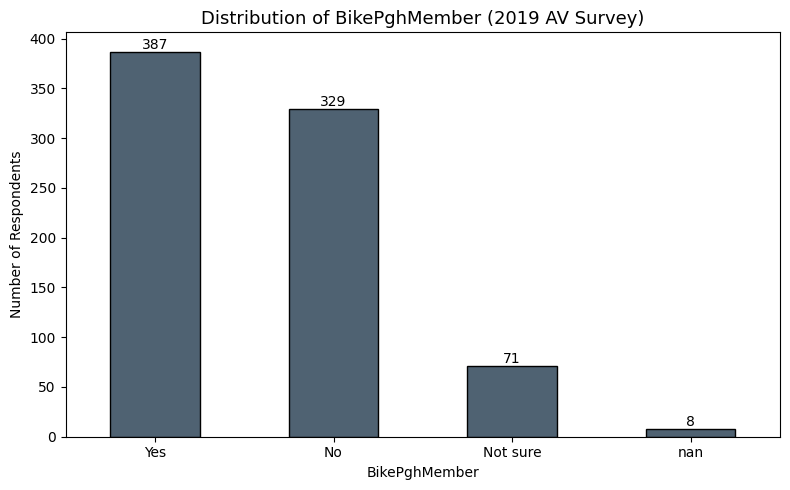

In [26]:
# Bar chart for Gender — ordered by frequency (appropriate for nominal data)
bikepgh_table_sorted = df_av['BikePghMember'].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = bikepgh_table_sorted.plot(kind='bar', color='#4f6272', edgecolor='black', ax=ax)

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

ax.set_title('Distribution of BikePghMember (2019 AV Survey)', fontsize=13)
ax.set_xlabel('BikePghMember')
ax.set_ylabel('Number of Respondents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation — BikePghMember:**
Dominant category: Yes (387 responses, 48.7%) is the most frequent — nearly half of all respondents are Bike PGH members.

Balanced? Not sure due to Nan values. Yes and No are close (48.7% vs 41.4%), but Not sure (8.9%) is a clear minority. 

Is it innapropiate to calculate the mean for the ordinal values?:

### 1.3.2 Likert-type (ordinal) variable: `SafetyAV`

In [27]:
# Frequency table for SafeAv (Likert-type ordinal variable, 1=very unsafe, 5=very safe)
counts = df_av['SafeAv'].value_counts(dropna=False).sort_index()
pct = df_av['SafeAv'].value_counts(normalize=True, dropna=False).sort_index().mul(100).round(1)

safeav_table = pd.DataFrame({'Count': counts, 'Percentage (%)': pct})
safeav_table.index.name = 'SafeAv (1=very unsafe, 5=very safe)'
display(safeav_table)

,Count,Percentage (%)
"SafeAv (1=very unsafe, 5=very safe)",,
1.0,57,7.2
2.0,68,8.6
3.0,179,22.5
4.0,249,31.3
5.0,234,29.4
NaN,8,1.0


In [28]:
# Frequency table for SafeAv (Likert-type ordinal variable, 1=very unsafe, 5=very safe)
counts = df_av['SafeAv'].value_counts(dropna=False).sort_index()
pct = df_av['SafeAv'].value_counts(normalize=True, dropna=False).sort_index().mul(100).round(1)

safeav_table = pd.DataFrame({'Count': counts, 'Percentage (%)': pct})
safeav_table.index.name = 'SafeAv (1=very unsafe, 5=very safe)'
display(safeav_table)

,Count,Percentage (%)
"SafeAv (1=very unsafe, 5=very safe)",,
1.0,57,7.2
2.0,68,8.6
3.0,179,22.5
4.0,249,31.3
5.0,234,29.4
NaN,8,1.0


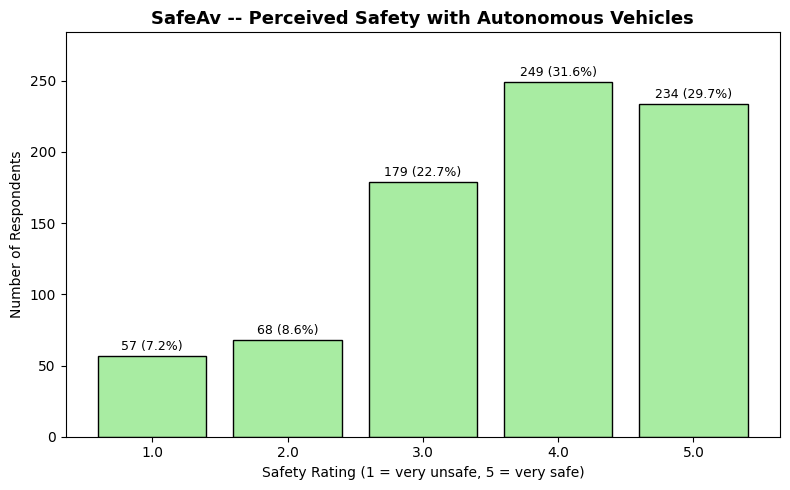

In [30]:
# Bar chart for SafeAv -- sorted by scale value (preserving ordinal order)
safeav_sorted = df_av['SafeAv'].value_counts(dropna=True).sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(safeav_sorted.index.astype(str), safeav_sorted.values,
              color='#a8eca2', edgecolor='black')

for bar, val in zip(bars, safeav_sorted.values):
    pct = val / safeav_sorted.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val} ({pct:.1f}%)", ha='center', va='bottom', fontsize=9)

ax.set_title('SafeAv -- Perceived Safety with Autonomous Vehicles', fontsize=13, fontweight='bold')
ax.set_xlabel('Safety Rating (1 = very unsafe, 5 = very safe)')
ax.set_ylabel('Number of Respondents')
ax.set_ylim(0, safeav_sorted.max() + 35)
plt.tight_layout()
plt.show()

**Interpretation — SafeAv:**
- **Dominant category:** Rating **4** with 249 responses (31.3%) is the most frequent. Ratings 4 and 5 together account for **60.7%** of all responses, meaning the majority of respondents feel safe or very safe sharing the road with autonomous vehicles.
- **Balance:** The categories are **not balanced**. The distribution is clearly skewed towards the positive (safe) end of the scale. Ratings 1 and 2 together only make up 15.8%, while ratings 4 and 5 make up 60.7%. Rating 3 (neutral) sits in the middle at 22.5%.(left skeewed)
- The bars are ordered from 1 to 5, preserving the **ordinal nature** of the Likert scale.

### Why is it inappropriate to calculate a mean for the ordinal variable?

A Likert scale is **ordinal**, meaning the categories have a meaningful order, but the **distances between categories are not guaranteed to be equal**. The difference between "1 — very unsafe" and "2 — somewhat unsafe" is not necessarily the same as between "4 — somewhat safe" and "5 — very safe."

Calculating a mean assumes equal intervals (i.e., an interval or ratio scale), which is not justified for ordinal data. Appropriate summary measures for ordinal data are the **median** and the **mode**. Some researchers still report means for Likert-type data for practical comparisons, but this should be done with caution and explicitly acknowledged.

---
# 2) Degradation Measurement of Robot Arm Position Accuracy

## 2.1 Select one trial for an experimental condition

In [ ]:
# Load the combined parquet dataset prepared in the previous lab (adjust filepath if needed)
df_robot_all = pd.read_csv("data/robot_position_accuracy/ur5_combined.csv")
print(f"Full dataset shape: {df_robot_all.shape}")
df_robot_all.head()

Full dataset shape: (153658, 77)


,robot_time,robot_target_joint_positions_j1,robot_target_joint_positions_j2,robot_target_joint_positions_j3,robot_target_joint_positions_j4,robot_target_joint_positions_j5,robot_target_joint_positions_j6,robot_actual_joint_positions_j1,robot_actual_joint_positions_j2,robot_actual_joint_positions_j3,...,robot_joint_temp_j1,robot_joint_temp_j2,robot_joint_temp_j3,robot_joint_temp_j4,robot_joint_temp_j5,robot_joint_temp_j6,cold_start,speed,payload_lb,trial_number
0,747.248,-26.880069,-79.911609,57.095392,-157.771764,-105.009613,-44.724779,-26.876620,-79.910908,57.096775,...,25.209991,26.714735,26.712410,29.805393,28.690552,29.992847,True,fullspeed,4.5,1
1,747.256,-26.880069,-79.911609,57.095392,-157.771764,-105.009613,-44.724779,-26.876620,-79.910225,57.096092,...,25.209991,26.714735,26.712410,29.805393,28.690552,29.992847,True,fullspeed,4.5,1
2,747.264,-26.880069,-79.911609,57.095392,-157.771764,-105.009613,-44.724779,-26.879380,-79.909542,57.097485,...,25.209991,26.714735,26.712410,29.805393,28.690552,29.992847,True,fullspeed,4.5,1
3,747.272,-26.880069,-79.911609,57.095392,-157.771764,-105.009613,-44.724779,-26.879380,-79.910908,57.096092,...,25.209991,26.714735,26.712410,29.805393,28.690552,29.992847,True,fullspeed,4.5,1
4,747.280,-26.880069,-79.911609,57.095392,-157.771764,-105.009613,-44.724779,-26.877303,-79.909542,57.096775,...,25.209991,26.714735,26.714169,29.805393,28.691496,29.993563,True,fullspeed,4.5,1


In [ ]:
# Select one experimental condition: payload=4.5 lbs, full speed, cold start, trial 1
df_robot = df_robot_all[
    (df_robot_all['payload_lb'] == 4.5) &
    (df_robot_all['speed'] == 'fullspeed') &
    (df_robot_all['cold_start'] == True) &
    (df_robot_all['trial_number'] == 1)
].copy()

print(f"Filtered dataset shape: {df_robot.shape}")
df_robot.head()

Filtered dataset shape: (7010, 77)


,robot_time,robot_target_joint_positions_j1,robot_target_joint_positions_j2,robot_target_joint_positions_j3,robot_target_joint_positions_j4,robot_target_joint_positions_j5,robot_target_joint_positions_j6,robot_actual_joint_positions_j1,robot_actual_joint_positions_j2,robot_actual_joint_positions_j3,...,robot_joint_temp_j1,robot_joint_temp_j2,robot_joint_temp_j3,robot_joint_temp_j4,robot_joint_temp_j5,robot_joint_temp_j6,cold_start,speed,payload_lb,trial_number
0,747.248,-26.880069,-79.911609,57.095392,-157.771764,-105.009613,-44.724779,-26.876620,-79.910908,57.096775,...,25.209991,26.714735,26.712410,29.805393,28.690552,29.992847,True,fullspeed,4.5,1
1,747.256,-26.880069,-79.911609,57.095392,-157.771764,-105.009613,-44.724779,-26.876620,-79.910225,57.096092,...,25.209991,26.714735,26.712410,29.805393,28.690552,29.992847,True,fullspeed,4.5,1
2,747.264,-26.880069,-79.911609,57.095392,-157.771764,-105.009613,-44.724779,-26.879380,-79.909542,57.097485,...,25.209991,26.714735,26.712410,29.805393,28.690552,29.992847,True,fullspeed,4.5,1
3,747.272,-26.880069,-79.911609,57.095392,-157.771764,-105.009613,-44.724779,-26.879380,-79.910908,57.096092,...,25.209991,26.714735,26.712410,29.805393,28.690552,29.992847,True,fullspeed,4.5,1
4,747.280,-26.880069,-79.911609,57.095392,-157.771764,-105.009613,-44.724779,-26.877303,-79.909542,57.096775,...,25.209991,26.714735,26.714169,29.805393,28.691496,29.993563,True,fullspeed,4.5,1


**Chosen condition:** Load = 4.5 lbs, full speed, cold start, trial 1.

We chose this condition as a representative baseline run (high load, full speed, cold robot).

## 2.2 Compute the difference between actual and target position in J2 and J3

The difference `actual - target` tells us how far the robot's actual joint position deviated from the planned target position during operation. We inspect this for joints J2 and J3.


In [ ]:
# Identifify the correct column names for actual and target positions
current_cols = [col for col in df_robot.columns if 'position' in col.lower()]
print("Available position columns:")
print(current_cols)

Available position columns:
['robot_target_joint_positions_j1', 'robot_target_joint_positions_j2', 'robot_target_joint_positions_j3', 'robot_target_joint_positions_j4', 'robot_target_joint_positions_j5', 'robot_target_joint_positions_j6', 'robot_actual_joint_positions_j1', 'robot_actual_joint_positions_j2', 'robot_actual_joint_positions_j3', 'robot_actual_joint_positions_j4', 'robot_actual_joint_positions_j5', 'robot_actual_joint_positions_j6']


In [ ]:

# Example for snake_case columns:
actual_j2_col = 'robot_actual_joint_positions_j2'   
target_j2_col = 'robot_target_joint_positions_j2'   
actual_j3_col = 'robot_actual_joint_positions_j3'   
target_j3_col = 'robot_target_joint_positions_j3'   

df_robot['diff_position_j2'] = df_robot[actual_j2_col] - df_robot[target_j2_col]
df_robot['diff_position_j3'] = df_robot[actual_j3_col] - df_robot[target_j3_col]

df_robot[['diff_position_j2', 'diff_position_j3']].describe() # descriptive statistics for the difference columns

,diff_position_j2,diff_position_j3
count,7010.000000,7010.000000
mean,-0.001019,0.000863
std,0.012816,0.009689
min,-0.067509,-0.050115
25%,-0.004473,-0.002714
50%,-0.001325,0.001384
75%,0.002750,0.004834
max,0.068525,0.061875


### Comparison of descriptive statistics

In [ ]:
# Side-by-side descriptive statistics including skewness and kurtosis
desc = df_robot[['diff_position_j2', 'diff_position_j3']].describe()
desc.loc['skewness'] = df_robot[['diff_position_j2', 'diff_position_j3']].skew()
desc.loc['kurtosis'] = df_robot[['diff_position_j2', 'diff_position_j3']].kurtosis()
desc.loc['median'] = df_robot[['diff_position_j2', 'diff_position_j3']].median()
display(desc)

,diff_position_j2,diff_position_j3
count,7010.000000,7010.000000
mean,-0.001019,0.000863
std,0.012816,0.009689
min,-0.067509,-0.050115
25%,-0.004473,-0.002714
50%,-0.001325,0.001384
75%,0.002750,0.004834
max,0.068525,0.061875
skewness,-0.166149,-0.152242
kurtosis,4.786510,5.865212


Central Tendency:
Both means are very close to 0 (J2: −0.001, J3: +0.001), meaning the robot arm follows the target current accurately on average with no consistent over- or under-shooting. Mean and median are nearly identical, confirming this.

Spread:
The standard deviation is small (J2: 0.013, J3: 0.010), so most values stay tight around 0. However, the min/max values are far larger than the quartiles suggest — meaning occasional large spikes occur despite the generally precise behavior.

Skewness:
Both distributions are nearly symmetric (skewness ≈ −0.15 to −0.17). 

Kurtosis:
Both values are well above 3 (J2: 4.79, J3: 5.87), meaning the distributions have heavier tails than a normal distribution

Summary:
The robot tracks the target current very well most of the time, but occasionally produces notable deviations.



### Histograms with normal fit

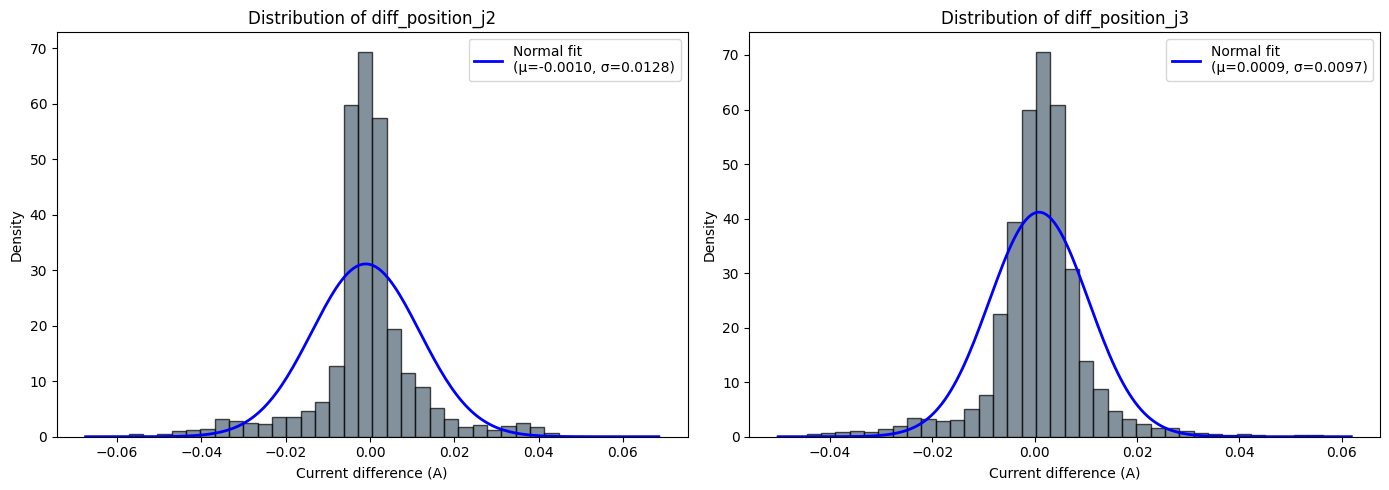

In [ ]:
diff_cols = ['diff_position_j2', 'diff_position_j3'] # columns to plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # create 1 row and 2 columns of subplots

for i, col in enumerate(diff_cols): 
    ax = axes[i]# Select the data for the current column
    data = df_robot[col].dropna() # drop missing values for plotting
    
    # Histogram (density for comparison with normal curve)
    # 40 bins, custom color, black edges, density=True for normalization, alpha for transparency
    ax.hist(data, bins=40, color='#4f6272', edgecolor='black', density=True, alpha=0.7)
    
    # Fitted normal distribution,
    mu, std = stats.norm.fit(data)
    # Create x values for the normal curve
    x = np.linspace(data.min(), data.max(), 200)
    # Plot the normal distribution curve
    #stats.norm.pdf(x, mu, std) gives the y values of the normal distribution with mean mu and std at each x
    # b- blue line, linewidth=2
    ax.plot(x, stats.norm.pdf(x, mu, std), 'b-', linewidth=2, label=f'Normal fit\n(μ={mu:.4f}, σ={std:.4f})')
    
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.set_xlabel('Current difference (A)')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

### Boxplots

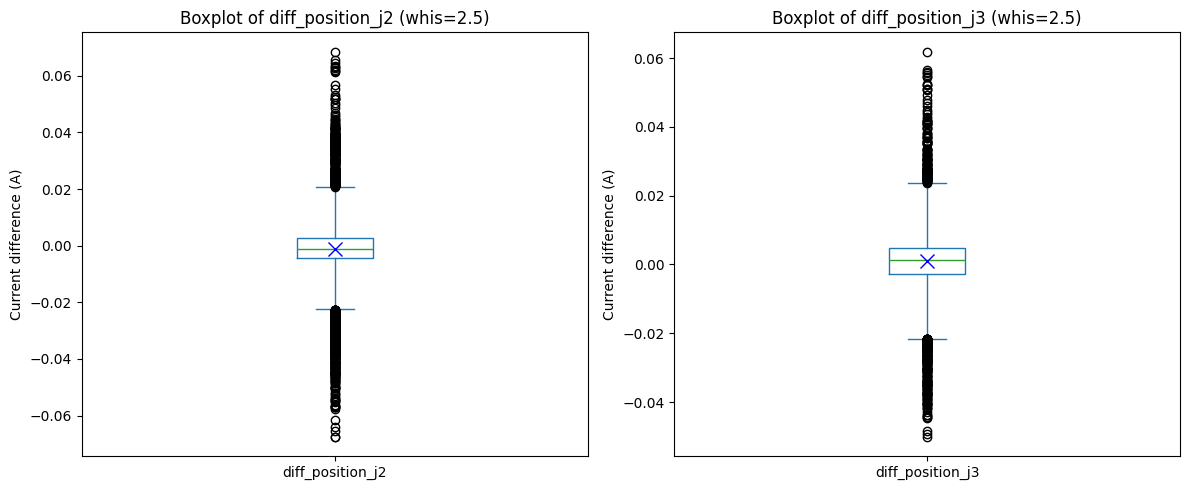

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(diff_cols):
    ax = axes[i]
    df_robot[[col]].dropna().plot(
        kind='box', ax=ax, vert=True,
        showmeans=True,
        meanprops=dict(marker='x', markeredgecolor='blue', markerfacecolor='blue', markersize=10),
        # Default whisker length is 1.5 * IQR; we use 2.5 * IQR as specified in the task
        whis=2.5
    )
    ax.set_title(f'Boxplot of {col} (whis=2.5)', fontsize=12)
    ax.set_ylabel('Current difference (A)')

plt.tight_layout()
plt.show()

### Outlier detection (2.5 × IQR)

In [ ]:
for col in diff_cols:
    data = df_robot[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 2.5 * IQR 
    upper_bound = Q3 + 2.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    print(f"--- {col} ---")
    print(f"  Q1 = {Q1:.6f}, Q3 = {Q3:.6f}, IQR = {IQR:.6f}")
    print(f"  Lower bound: {lower_bound:.6f}")
    print(f"  Upper bound: {upper_bound:.6f}")
    print(f"  Number of outliers (2.5 × IQR): {len(outliers)} | Relative: {round(len(outliers)/df_robot.shape[0]*100,3)}%")
    print()

--- diff_position_j2 ---
  Q1 = -0.004473, Q3 = 0.002750, IQR = 0.007223
  Lower bound: -0.022529
  Upper bound: 0.020806
  Number of outliers (2.5 × IQR): 704 | Relative: 10.043%

--- diff_position_j3 ---
  Q1 = -0.002714, Q3 = 0.004834, IQR = 0.007548
  Lower bound: -0.021585
  Upper bound: 0.023705
  Number of outliers (2.5 × IQR): 360 | Relative: 5.136%



### Q-Q Plots

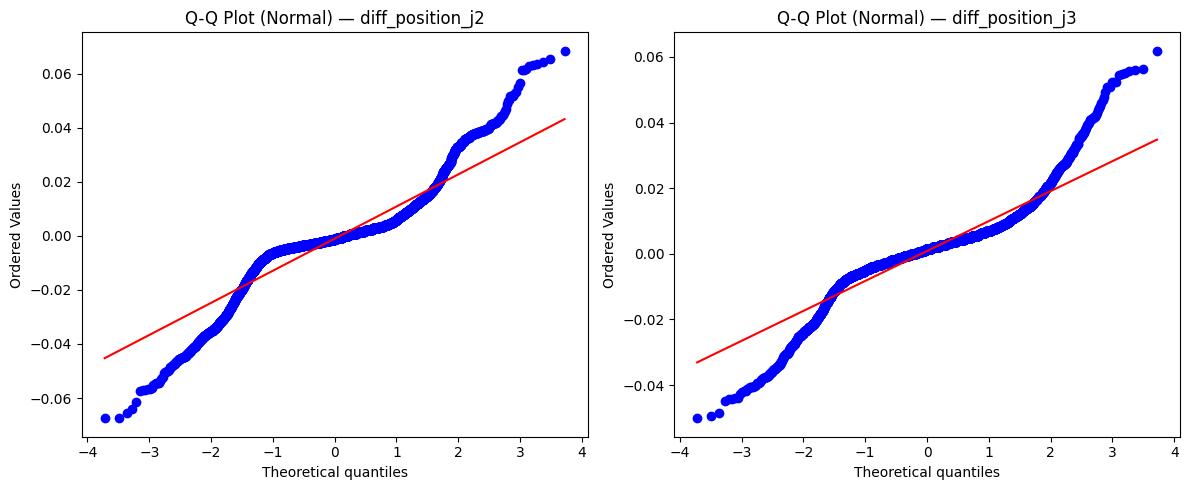

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(diff_cols):
    ax = axes[i]
    stats.probplot(df_robot[col].dropna(), dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot (Normal) — {col}', fontsize=12)

plt.tight_layout()
plt.show()

## 2.3 Answers to the questions

### Are there outliers based on a distance of at least 2.5 × IQR from the upper/lower quartile?

See the outlier counts printed above. Using the stricter 2.5 × IQR criterion (instead of the standard 1.5 × IQR), outliers are those data points that fall outside the range [Q1 − 2.5·IQR, Q3 + 2.5·IQR]. The boxplots with `whis=2.5` visualize this directly — any points plotted beyond the whiskers are flagged as outliers.
For J2 there are 704 outliers or about 10% of the data are outliers
For J3 there are 360 outliers or about 5% of the data are outliers

### Is the distribution symmetric or skewed?

We can assess symmetry from:
- The **skewness** values in the descriptive statistics table (values close to 0 indicate symmetry; positive values indicate right-skew, negative values indicate left-skew).
- The **histograms** — a visually symmetric bell shape vs. a tail extending to one side.
- The **boxplots** — if the median line is centered within the box and the whiskers are roughly equal in length, the distribution is approximately symmetric.

To be precise there is a little negative/left skewness für both J2 and J3, but in generell we would assume a neutral skewness

### Is it unimodal?

A unimodal distribution has a single peak. We can assess this from the **histograms** — if there is clearly one dominant peak, the distribution is unimodal. Multiple peaks would indicate bimodal or multimodal distributions, which could occur if different operating states are mixed.

In this case we have an unimodal distribution, as we can see in the plotted histogramm. There is one single peak around the value '0' for both J2 and J3.

### Is the normality assumption plausible? Why?

We assess normality through multiple perspectives:
1. **Histograms with normal fit:** Does the fitted normal curve approximate the observed data well?
2. **Q-Q plots:** If the data points closely follow the diagonal line, the normal distribution is a plausible model. Systematic deviations (S-shapes, heavy tails) suggest departures from normality.
3. **Skewness and kurtosis:** For a normal distribution, skewness ≈ 0 and excess kurtosis ≈ 0. Large deviations indicate non-normality.

1) As we can see in the plotted histogramm, the data is kind of fitted good by the normal curve. But because of the high peaks around '0' the normal curve doesn't approximate the data perfectly. 

2) The Q-Q plot makes this more clear. As we can observe there is kind of an S-Shape around the diagonal line, which indicates a small difference from the normality bahavior.

3) This one shows a normality behavior (skewness: J2: -0.166149	J3: -0.152242
kurtosis: J2: -0.001325	J3: 0.001384) for both J2 and J3 both values are near to zero (kurtosis shows a better result)
